In [1]:
!pip -q install ultralytics

In [ ]:
import os
import random
import zipfile
import shutil
import yaml
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from ultralytics import YOLO

In [3]:
SEED = 993
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)


seed_everything(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Seed:   {SEED}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU:    {torch.cuda.get_device_name(0)}')

Seed:   993
Device: cpu


## Подготовка данных


In [ ]:
KAGGLE_INPUT_ROOT = Path('/kaggle/input')
KAGGLE_WORKING_ROOT = Path('/kaggle/working')
LOCAL_ROOT = Path.cwd()

EXPECTED_STRUCTURE = {
    'train_images': Path('train/train/images'),
    'train_labels': Path('train/train/labels'),
    'test_images': Path('test/test/images'),
    'sample_submission': Path('sample_submission.csv'),
}

def looks_like_competition_dataset(root: Path) -> bool:
    return all((root / rel_path).exists() for rel_path in EXPECTED_STRUCTURE.values())

def is_macos_artifact(filename: str) -> bool:
    parts = Path(filename).parts

    if '__MACOSX' in parts:
        return True

    if any(part.startswith('._') for part in parts):
        return True

    if any(part == '.DS_Store' for part in parts):
        return True

    return False

def extract_local_zip_if_needed() -> None:
    if KAGGLE_INPUT_ROOT.exists():
        return

    possible_roots = [
        LOCAL_ROOT,
        LOCAL_ROOT / 'competition_data',
        LOCAL_ROOT / '2026-cv-competition',
        LOCAL_ROOT / 'data',
        LOCAL_ROOT / 'dataset',
        LOCAL_ROOT / 'datasets',
    ]

    for root in possible_roots:
        if root.exists() and root.is_dir() and looks_like_competition_dataset(root):
            print(f'[Local] Датасет уже распакован: {root}')
            return

    zip_candidates = [
        LOCAL_ROOT / '2026-cv-competition.zip',
        LOCAL_ROOT / 'competition.zip',
        LOCAL_ROOT / 'data.zip',
    ]

    zip_candidates += sorted(LOCAL_ROOT.rglob('*.zip'))

    unique_zip_candidates = []
    seen = set()

    for path in zip_candidates:
        path = path.resolve()
        if path not in seen:
            seen.add(path)
            unique_zip_candidates.append(path)

    valid_zip_candidates = [
        path
        for path in unique_zip_candidates
        if path.exists() and path.is_file() and zipfile.is_zipfile(path)
    ]

    if not valid_zip_candidates:
        print('[Local] Zip-архив не найден.')
        return

    zip_path = valid_zip_candidates[0]
    extract_root = LOCAL_ROOT / 'competition_data'

    print(f'[Local] Найден архив: {zip_path}')
    print(f'[Local] Распаковываю в: {extract_root}')

    if extract_root.exists():
        shutil.rmtree(extract_root)

    extract_root.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zf:
        for member in zf.infolist():
            if not is_macos_artifact(member.filename):
                zf.extract(member, extract_root)

    print('[Local] Архив распакован.')

def find_dataset_root() -> Path:
    candidates = []

    if KAGGLE_INPUT_ROOT.exists():
        if looks_like_competition_dataset(KAGGLE_INPUT_ROOT):
            candidates.append(KAGGLE_INPUT_ROOT)

        for path in KAGGLE_INPUT_ROOT.rglob('*'):
            if path.is_dir() and looks_like_competition_dataset(path):
                candidates.append(path)

    local_search_roots = [
        LOCAL_ROOT,
        LOCAL_ROOT / 'competition_data',
        LOCAL_ROOT / '2026-cv-competition',
        LOCAL_ROOT / 'data',
        LOCAL_ROOT / 'dataset',
        LOCAL_ROOT / 'datasets',
    ]

    for root in local_search_roots:
        if root.exists() and root.is_dir():
            if looks_like_competition_dataset(root):
                candidates.append(root)

            for path in root.rglob('*'):
                if path.is_dir() and looks_like_competition_dataset(path):
                    candidates.append(path)

    candidates = sorted(set(candidates), key=lambda p: len(str(p)))

    if candidates:
        print('Найден датасет:')
        print(candidates[0])
        return candidates[0]

    print('Датасет не найден.')
    print(f'Текущая папка: {LOCAL_ROOT.resolve()}')

    print('\nЧто лежит рядом с ноутбуком:')
    for path in sorted(LOCAL_ROOT.iterdir()):
        print(path)

    raise FileNotFoundError(
        'Не удалось найти датасет. Ожидается структура: '
        'train/train/images, train/train/labels, test/test/images, sample_submission.csv'
    )

extract_local_zip_if_needed()

INPUT_DIR = find_dataset_root()

if KAGGLE_WORKING_ROOT.exists():
    WORKING_DIR = KAGGLE_WORKING_ROOT
else:
    WORKING_DIR = LOCAL_ROOT

TRAIN_IMAGES = INPUT_DIR / 'train' / 'train' / 'images'
TRAIN_LABELS = INPUT_DIR / 'train' / 'train' / 'labels'
SUBMISSION_CSV = INPUT_DIR / 'sample_submission.csv'
TEST_IMAGES = INPUT_DIR / 'test' / 'test' / 'images'

print(f'INPUT_DIR: {INPUT_DIR}')
print(f'WORKING_DIR: {WORKING_DIR}')
print(f'TRAIN_IMAGES: {TRAIN_IMAGES}')
print(f'TRAIN_LABELS: {TRAIN_LABELS}')
print(f'TEST_IMAGES: {TEST_IMAGES}')
print(f'SUBMISSION_CSV: {SUBMISSION_CSV}')

[Local] Найден архив: /Users/ilyutkinn/Desktop/CVCompetition/2026-cv-competition.zip
[Local] Распаковываю в: /Users/ilyutkinn/Desktop/CVCompetition/competition_data
[Local] Архив распакован.
Найден датасет:
/Users/ilyutkinn/Desktop/CVCompetition/competition_data
INPUT_DIR: /Users/ilyutkinn/Desktop/CVCompetition/competition_data
WORKING_DIR: /Users/ilyutkinn/Desktop/CVCompetition
TRAIN_IMAGES: /Users/ilyutkinn/Desktop/CVCompetition/competition_data/train/train/images
TRAIN_LABELS: /Users/ilyutkinn/Desktop/CVCompetition/competition_data/train/train/labels
TEST_IMAGES: /Users/ilyutkinn/Desktop/CVCompetition/competition_data/test/test/images
SUBMISSION_CSV: /Users/ilyutkinn/Desktop/CVCompetition/competition_data/sample_submission.csv


In [5]:
# ── Пути к данным ─────────────────────────────────────────────────────────
TRAIN_IMAGES   = INPUT_DIR / 'train' / 'train' / 'images'
TRAIN_LABELS   = INPUT_DIR / 'train' / 'train' / 'labels'
SUBMISSION_CSV = INPUT_DIR / 'sample_submission.csv'
TEST_IMAGES    = INPUT_DIR / 'test' / 'test' / 'images'

def collect_images(folder: Path) -> list:
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTENSIONS])


train_img_paths = collect_images(TRAIN_IMAGES)
train_lbl_paths = sorted(TRAIN_LABELS.glob('*.txt'))
test_img_paths  = collect_images(TEST_IMAGES)

print(f'Train: {len(train_img_paths)} изображений, {len(train_lbl_paths)} лейблов')
print(f'Test: {len(test_img_paths)} изображений')

# Проверка парности изображений и лейблов
img_stems = {p.stem for p in train_img_paths}
lbl_stems = {p.stem for p in train_lbl_paths}
if img_stems - lbl_stems:
    print(f'[WARN] {len(img_stems - lbl_stems)} изображений без лейблов')
if lbl_stems - img_stems:
    print(f'[WARN] {len(lbl_stems - img_stems)} лейблов без изображений')
if not (img_stems - lbl_stems) and not (lbl_stems - img_stems):
    print('[OK]   Все изображения имеют соответствующий лейбл')

Train: 1697 изображений, 1697 лейблов
Test: 424 изображений
[OK]   Все изображения имеют соответствующий лейбл



## Анализ данных

### 3.1 Парсинг разметки

In [6]:
def parse_yolo_labels(label_paths: list) -> tuple:
    """
    Парсит YOLO-разметку: class_id x_center y_center width height (нормализованные).
    Возвращает: (list_of_class_ids, objects_per_image, list_of_bboxes)
    """
    all_class_ids = []
    objects_per_image = []
    all_bboxes = []  # (class_id, x_center, y_center, w, h)

    for lbl_path in label_paths:
        content = lbl_path.read_text().strip()
        if not content:
            objects_per_image.append(0)
            continue
        lines = [l for l in content.splitlines() if l.strip()]
        objects_per_image.append(len(lines))
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:5])
            all_class_ids.append(cls_id)
            all_bboxes.append((cls_id, xc, yc, bw, bh))

    return all_class_ids, objects_per_image, all_bboxes


all_class_ids, objects_per_image, all_bboxes = parse_yolo_labels(train_lbl_paths)
class_counts = Counter(all_class_ids)
num_classes  = len(class_counts)

print(f'Классов:{num_classes}')
print(f'Всего объектов:{len(all_class_ids)}')
print(f'Изображений без объектов: {objects_per_image.count(0)}')
print()
print('Распределение классов:')
for cls_id in sorted(class_counts):
    print(f'Класс {cls_id}:{class_counts[cls_id]} объектов')

Классов:52
Всего объектов:10498
Изображений без объектов: 0

Распределение классов:
Класс 0:156 объектов
Класс 1:96 объектов
Класс 2:149 объектов
Класс 3:143 объектов
Класс 4:134 объектов
Класс 5:197 объектов
Класс 6:165 объектов
Класс 7:250 объектов
Класс 8:139 объектов
Класс 9:177 объектов
Класс 10:263 объектов
Класс 11:147 объектов
Класс 12:159 объектов
Класс 13:256 объектов
Класс 14:188 объектов
Класс 15:83 объектов
Класс 16:170 объектов
Класс 17:162 объектов
Класс 18:163 объектов
Класс 19:183 объектов
Класс 20:215 объектов
Класс 21:179 объектов
Класс 22:249 объектов
Класс 23:185 объектов
Класс 24:190 объектов
Класс 25:186 объектов
Класс 26:327 объектов
Класс 27:153 объектов
Класс 28:156 объектов
Класс 29:276 объектов
Класс 30:137 объектов
Класс 31:187 объектов
Класс 32:290 объектов
Класс 33:163 объектов
Класс 34:289 объектов
Класс 35:136 объектов
Класс 36:182 объектов
Класс 37:183 объектов
Класс 38:158 объектов
Класс 39:274 объектов
Класс 40:277 объектов
Класс 41:93 объектов
Класс

### 3.2 Размеры изображений

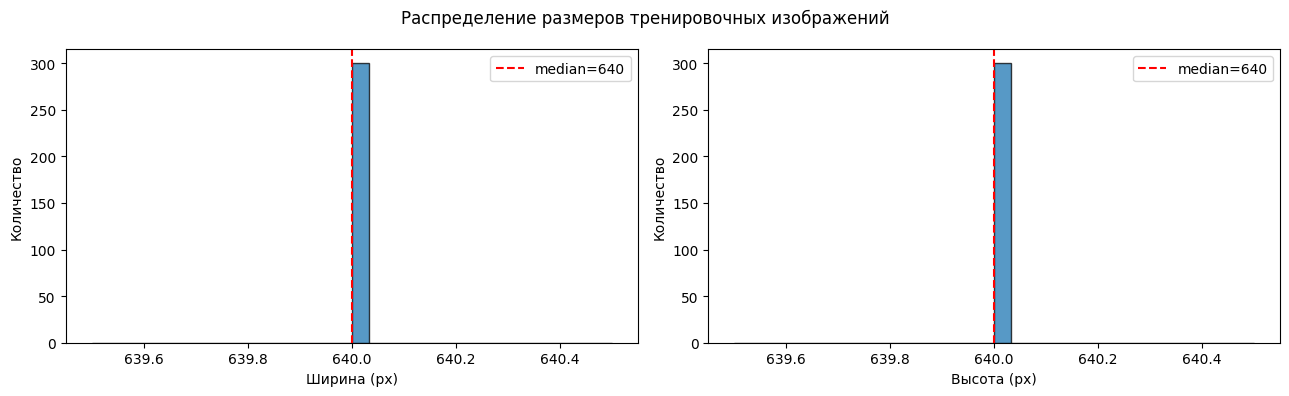

Ширина:  min=640, max=640, median=640
Высота:  min=640, max=640, median=640


In [7]:
sample_paths = random.sample(train_img_paths, min(300, len(train_img_paths)))
widths, heights = [], []
for p in sample_paths:
    w, h = Image.open(p).size
    widths.append(w)
    heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, values, label in zip(axes, [widths, heights], ['Ширина (px)', 'Высота (px)']):
    ax.hist(values, bins=30, edgecolor='black', alpha=0.75)
    ax.set_xlabel(label)
    ax.set_ylabel('Количество')
    ax.axvline(np.median(values), color='red', linestyle='--',
               label=f'median={np.median(values):.0f}')
    ax.legend()
plt.suptitle('Распределение размеров тренировочных изображений')
plt.tight_layout()
plt.show()

print(f'Ширина:  min={min(widths)}, max={max(widths)}, median={np.median(widths):.0f}')
print(f'Высота:  min={min(heights)}, max={max(heights)}, median={np.median(heights):.0f}')

### 3.3 Распределение классов и объектов на изображение

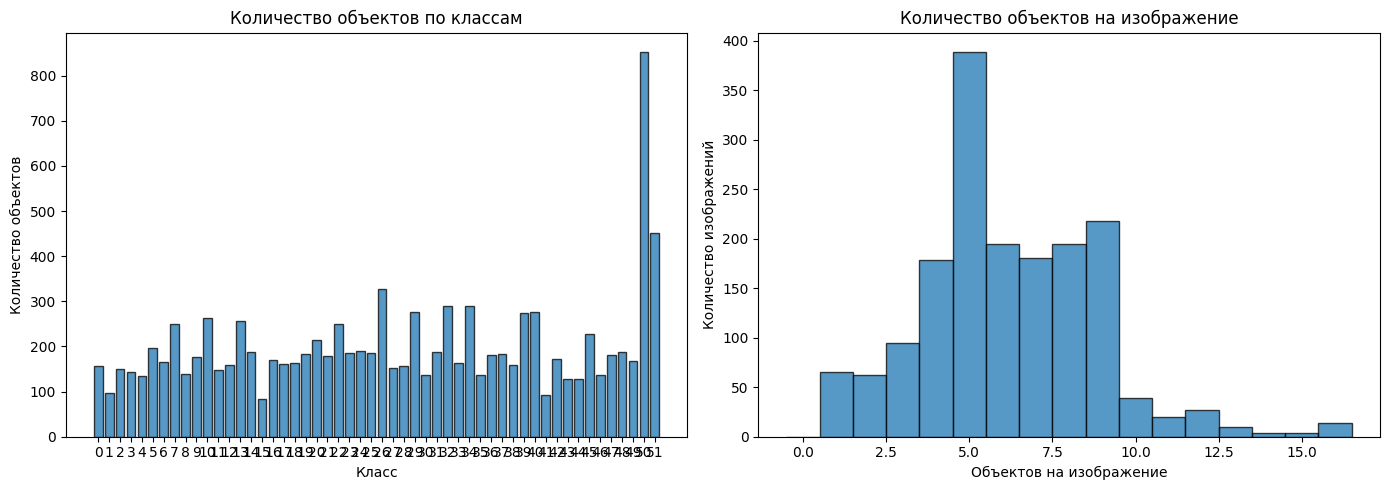

Объектов на изображение: min=1, max=16, mean=6.19, median=6


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cls_ids_sorted = sorted(class_counts)
ax = axes[0]
ax.bar([str(c) for c in cls_ids_sorted],
       [class_counts[c] for c in cls_ids_sorted],
       edgecolor='black', alpha=0.75)
ax.set_title('Количество объектов по классам')
ax.set_xlabel('Класс')
ax.set_ylabel('Количество объектов')

ax = axes[1]
max_obj = max(objects_per_image) if objects_per_image else 1
ax.hist(objects_per_image, bins=range(0, max_obj + 2),
        edgecolor='black', alpha=0.75, align='left')
ax.set_title('Количество объектов на изображение')
ax.set_xlabel('Объектов на изображение')
ax.set_ylabel('Количество изображений')

plt.tight_layout()
plt.show()

print(f'Объектов на изображение: '
      f'min={min(objects_per_image)}, max={max(objects_per_image)}, '
      f'mean={np.mean(objects_per_image):.2f}, median={np.median(objects_per_image):.0f}')

### 3.4 Размеры bbox

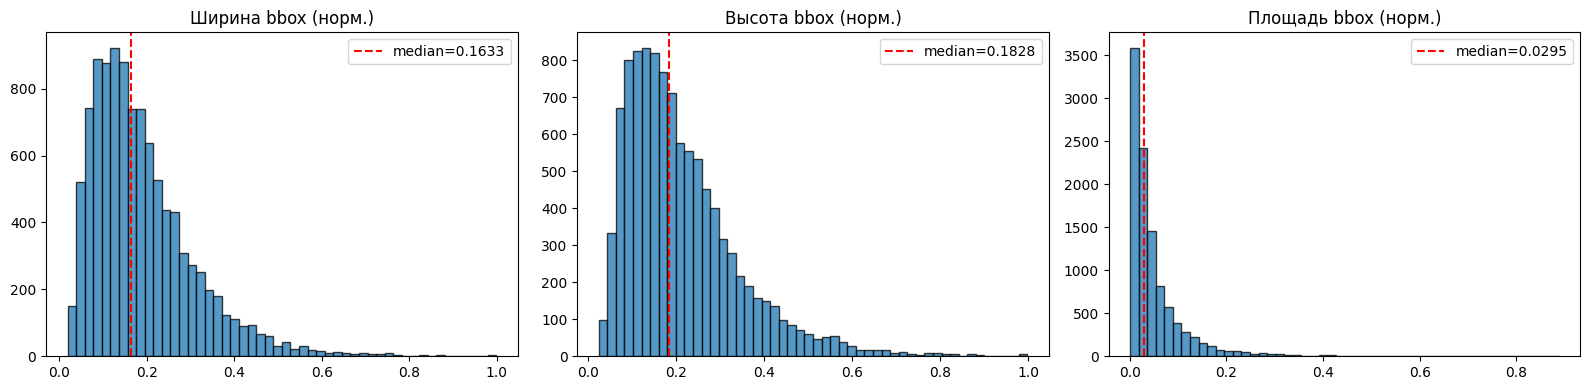

Ширина bbox:  min=0.0187, max=0.9984, mean=0.1899
Высота bbox:  min=0.0242, max=0.9984, mean=0.2127
Площадь bbox: min=0.000624, max=0.8871, mean=0.0513


In [9]:
bbox_ws    = [b[3] for b in all_bboxes]
bbox_hs    = [b[4] for b in all_bboxes]
bbox_areas = [w * h for w, h in zip(bbox_ws, bbox_hs)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, values, title in zip(
    axes,
    [bbox_ws, bbox_hs, bbox_areas],
    ['Ширина bbox (норм.)', 'Высота bbox (норм.)', 'Площадь bbox (норм.)'],
):
    ax.hist(values, bins=50, edgecolor='black', alpha=0.75)
    ax.set_title(title)
    ax.axvline(np.median(values), color='red', linestyle='--',
               label=f'median={np.median(values):.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'Ширина bbox:  min={min(bbox_ws):.4f}, max={max(bbox_ws):.4f}, mean={np.mean(bbox_ws):.4f}')
print(f'Высота bbox:  min={min(bbox_hs):.4f}, max={max(bbox_hs):.4f}, mean={np.mean(bbox_hs):.4f}')
print(f'Площадь bbox: min={min(bbox_areas):.6f}, max={max(bbox_areas):.4f}, mean={np.mean(bbox_areas):.4f}')

### 3.5 Тепловая карта центров объектов

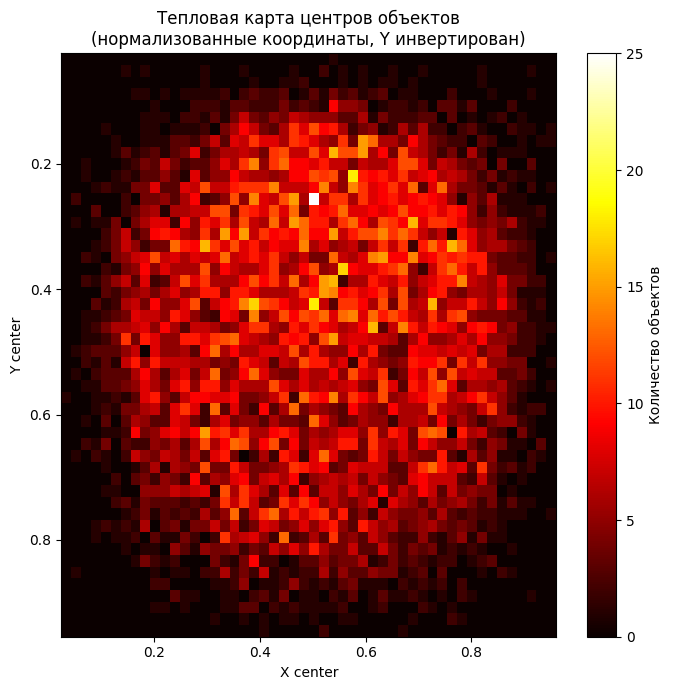

In [10]:
centers_x = [b[1] for b in all_bboxes]
centers_y = [b[2] for b in all_bboxes]

fig, ax = plt.subplots(figsize=(7, 7))
h2d = ax.hist2d(centers_x, centers_y, bins=50, cmap='hot')
plt.colorbar(h2d[3], ax=ax, label='Количество объектов')
ax.set_title('Тепловая карта центров объектов\n(нормализованные координаты, Y инвертирован)')
ax.set_xlabel('X center')
ax.set_ylabel('Y center')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.6 Примеры тренировочных изображений с разметкой

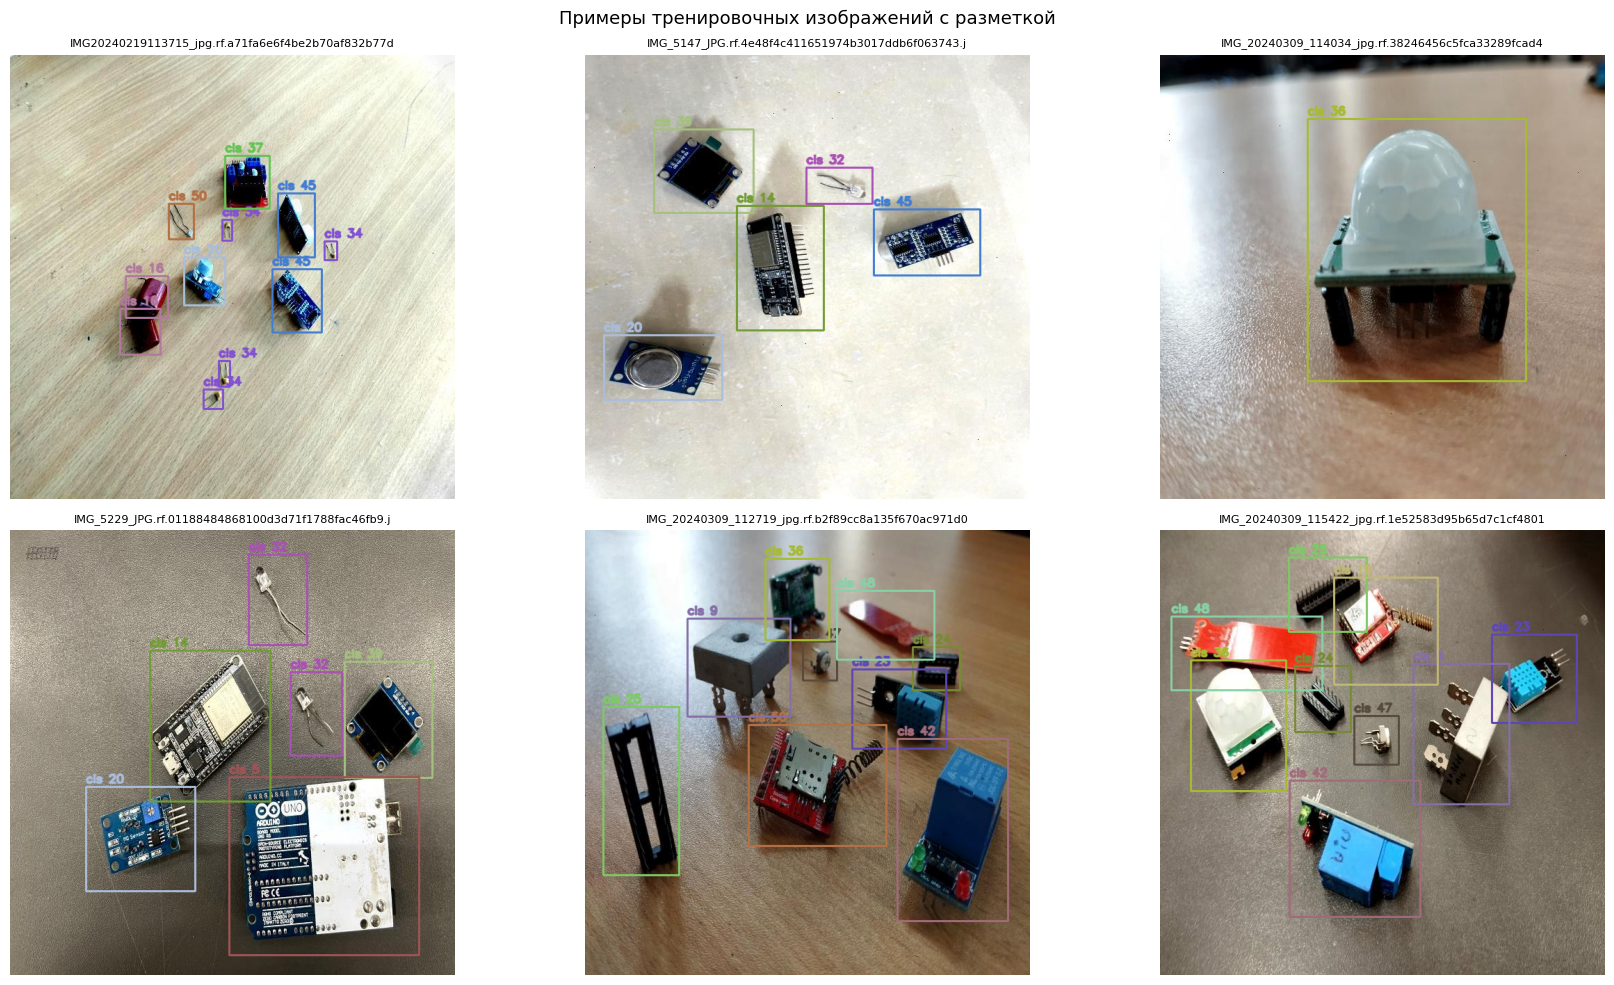

In [11]:
def draw_yolo_boxes(image_rgb: np.ndarray, label_path: Path,
                    color_map: dict) -> np.ndarray:
    """Рисует YOLO-боксы (x_center y_center w h, норм.) на изображении."""
    H, W = image_rgb.shape[:2]
    out = cv2.cvtColor(image_rgb.copy(), cv2.COLOR_RGB2BGR)

    if not label_path.exists():
        return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)

    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])
        x1 = int((xc - bw / 2) * W)
        y1 = int((yc - bh / 2) * H)
        x2 = int((xc + bw / 2) * W)
        y2 = int((yc + bh / 2) * H)
        color_rgb = color_map.get(cls_id, (255, 0, 0))
        color_bgr = color_rgb[::-1]
        cv2.rectangle(out, (x1, y1), (x2, y2), color_bgr, 2)
        cv2.putText(out, f'cls {cls_id}', (x1, max(y1 - 6, 14)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color_bgr, 2, cv2.LINE_AA)

    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)


np.random.seed(SEED)
color_map = {
    cls_id: tuple(np.random.randint(50, 220, 3).tolist())
    for cls_id in sorted(class_counts)
}

sample_idx = random.sample(range(len(train_img_paths)), min(6, len(train_img_paths)))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, idx in zip(axes.flatten(), sample_idx):
    img_path = train_img_paths[idx]
    lbl_path = TRAIN_LABELS / (img_path.stem + '.txt')
    img = np.array(Image.open(img_path).convert('RGB'))
    img_annotated = draw_yolo_boxes(img, lbl_path, color_map)
    ax.imshow(img_annotated)
    ax.set_title(img_path.name[:50], fontsize=8)
    ax.axis('off')

plt.suptitle('Примеры тренировочных изображений с разметкой', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Конфигурация датасета для YOLOv8

Разбиваем на **train / val = 85% / 15%**, создаём `dataset.yaml`.

In [12]:
def resolve_class_names(input_dir: Path, class_counts: Counter) -> dict:
    """Ищет имена классов в data.yaml / classes.txt. Иначе автогенерация."""
    for yaml_path in input_dir.glob('**/data.yaml'):
        cfg = yaml.safe_load(yaml_path.read_text())
        if 'names' in cfg:
            names = cfg['names']
            result = ({i: n for i, n in enumerate(names)} if isinstance(names, list)
                      else {int(k): v for k, v in names.items()})
            print(f'Имена классов из {yaml_path.name}: {result}')
            return result

    for txt_path in input_dir.glob('**/classes.txt'):
        names = [n.strip() for n in txt_path.read_text().splitlines() if n.strip()]
        result = {i: n for i, n in enumerate(names)}
        print(f'Имена классов из {txt_path.name}: {result}')
        return result

    result = {i: f'class_{i}' for i in sorted(class_counts)}
    print(f'Имена классов (автогенерация): {result}')
    return result


class_names = resolve_class_names(INPUT_DIR, class_counts)
print(f'Итого классов: {len(class_names)}')

Имена классов (автогенерация): {0: 'class_0', 1: 'class_1', 2: 'class_2', 3: 'class_3', 4: 'class_4', 5: 'class_5', 6: 'class_6', 7: 'class_7', 8: 'class_8', 9: 'class_9', 10: 'class_10', 11: 'class_11', 12: 'class_12', 13: 'class_13', 14: 'class_14', 15: 'class_15', 16: 'class_16', 17: 'class_17', 18: 'class_18', 19: 'class_19', 20: 'class_20', 21: 'class_21', 22: 'class_22', 23: 'class_23', 24: 'class_24', 25: 'class_25', 26: 'class_26', 27: 'class_27', 28: 'class_28', 29: 'class_29', 30: 'class_30', 31: 'class_31', 32: 'class_32', 33: 'class_33', 34: 'class_34', 35: 'class_35', 36: 'class_36', 37: 'class_37', 38: 'class_38', 39: 'class_39', 40: 'class_40', 41: 'class_41', 42: 'class_42', 43: 'class_43', 44: 'class_44', 45: 'class_45', 46: 'class_46', 47: 'class_47', 48: 'class_48', 49: 'class_49', 50: 'class_50', 51: 'class_51'}
Итого классов: 52


In [13]:
DATASET_DIR = WORKING_DIR / 'yolo_dataset'

for split in ('train', 'val'):
    (DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

# Разбиение train/val (85/15)
all_paths = collect_images(TRAIN_IMAGES)
random.seed(SEED)
random.shuffle(all_paths)

n_val = int(len(all_paths) * 0.15)
splits = {'val': all_paths[:n_val], 'train': all_paths[n_val:]}

for split_name, paths in splits.items():
    for img_path in paths:
        dst_img = DATASET_DIR / split_name / 'images' / img_path.name
        if not dst_img.exists():
            shutil.copy2(img_path, dst_img)
        src_lbl = TRAIN_LABELS / (img_path.stem + '.txt')
        dst_lbl = DATASET_DIR / split_name / 'labels' / src_lbl.name
        if src_lbl.exists() and not dst_lbl.exists():
            shutil.copy2(src_lbl, dst_lbl)

print(f'Train: {len(splits["train"])} изображений')
print(f'Val:{len(splits["val"])} изображений')

Train: 1443 изображений
Val:254 изображений


In [14]:
dataset_cfg = {
    'path': str(DATASET_DIR),
    'train': 'train/images',
    'val': 'val/images',
    'nc': len(class_names),
    'names': class_names,
}

YAML_PATH = DATASET_DIR / 'dataset.yaml'
YAML_PATH.write_text(yaml.dump(dataset_cfg, allow_unicode=True, default_flow_style=False))

print('dataset.yaml:')
print(YAML_PATH.read_text())

dataset.yaml:
names:
  0: class_0
  1: class_1
  2: class_2
  3: class_3
  4: class_4
  5: class_5
  6: class_6
  7: class_7
  8: class_8
  9: class_9
  10: class_10
  11: class_11
  12: class_12
  13: class_13
  14: class_14
  15: class_15
  16: class_16
  17: class_17
  18: class_18
  19: class_19
  20: class_20
  21: class_21
  22: class_22
  23: class_23
  24: class_24
  25: class_25
  26: class_26
  27: class_27
  28: class_28
  29: class_29
  30: class_30
  31: class_31
  32: class_32
  33: class_33
  34: class_34
  35: class_35
  36: class_36
  37: class_37
  38: class_38
  39: class_39
  40: class_40
  41: class_41
  42: class_42
  43: class_43
  44: class_44
  45: class_45
  46: class_46
  47: class_47
  48: class_48
  49: class_49
  50: class_50
  51: class_51
nc: 52
path: /Users/ilyutkinn/Desktop/CVCompetition/yolo_dataset
train: train/images
val: val/images



---
## 5. Обучение модели

Используем **YOLOv8m** — разумный компромисс между качеством и временем обучения.

| Модель       | Параметры | mAP50 (COCO) | Совет |
|--------------|-----------|--------------|-------|
| yolov8n      | 3.2M      | 37.3         | быстрый прогон, слабый скор |
| yolov8s      | 11.2M     | 44.9         | хороший baseline |
| **yolov8m**  | **25.9M** | **50.2**     | **рекомендуется** |
| yolov8l      | 43.7M     | 52.9         | лучше, если хватает GPU |
| yolov8x      | 68.2M     | 53.9         | максимум качества |

In [ ]:
MODEL_NAME = 'yolov8m.pt'
IMG_SIZE = 640 
EPOCHS = 50  
BATCH_SIZE = 16 

model = YOLO(MODEL_NAME)

train_results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=15,
    seed=SEED,
    deterministic=True,

    # --- аугментации ---
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,
    mixup=0.1,

    # --- оптимизатор ---
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,

    workers=4,
    project=str(WORKING_DIR / 'runs' / 'detect'),
    name='run',
    exist_ok=True,
    verbose=True,
)

New https://pypi.org/project/ultralytics/8.4.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.43 🚀 Python-3.13.3 torch-2.11.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/ilyutkinn/Desktop/CVCompetition/yolo_dataset/dataset.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_sc

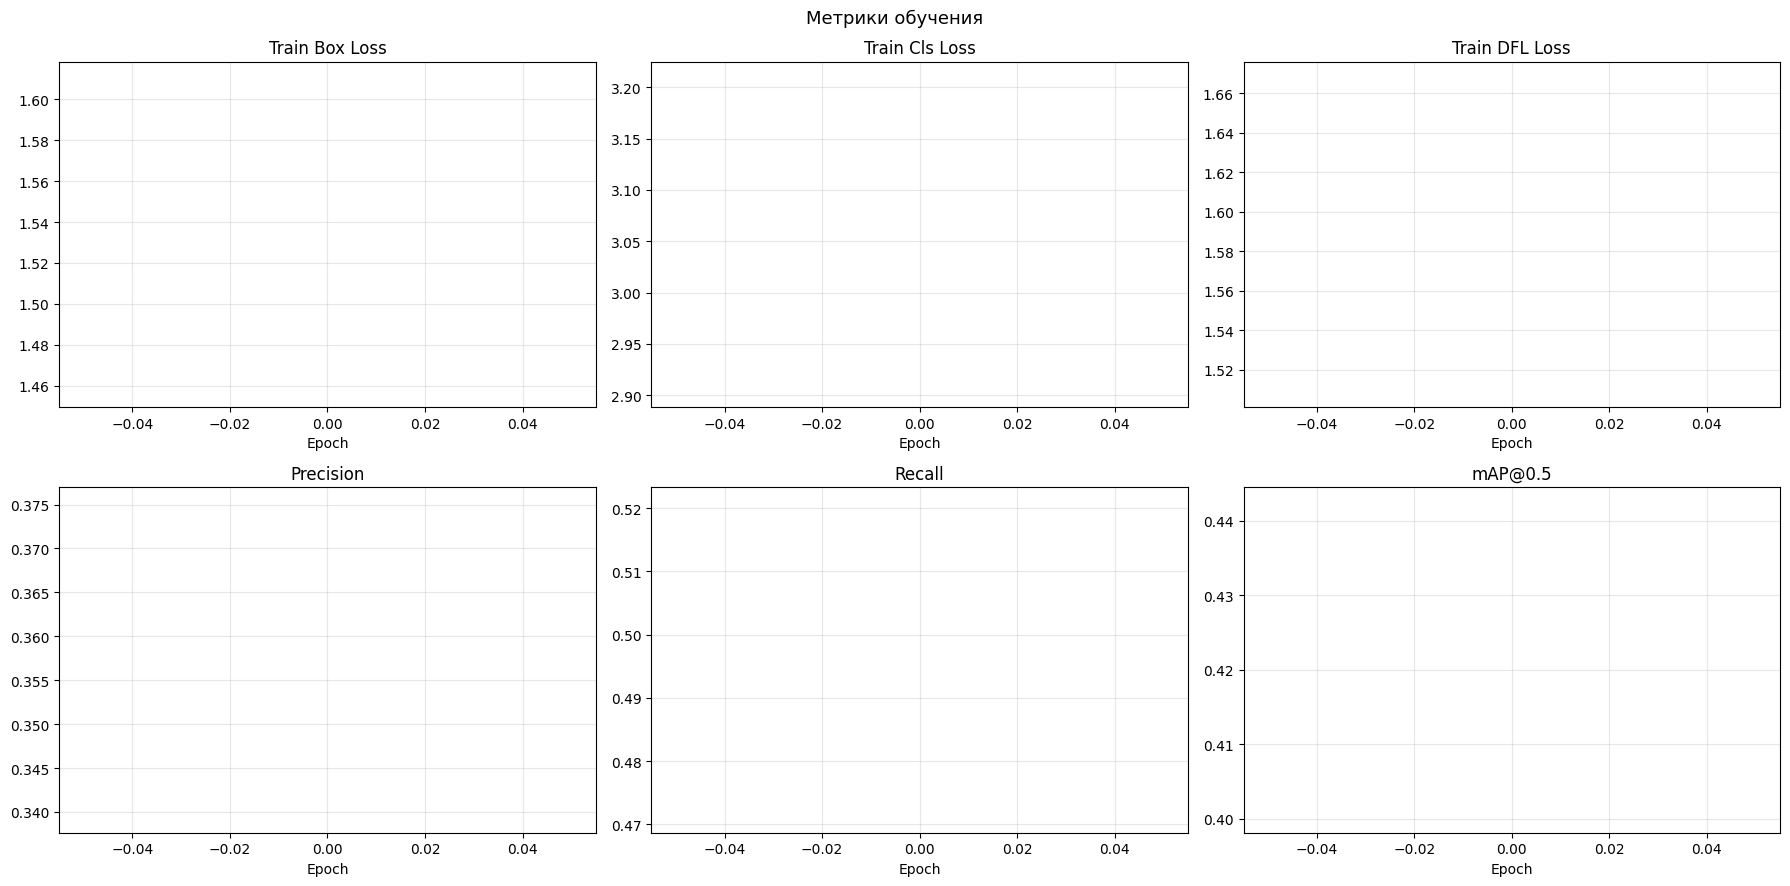

In [ ]:
# Кривые обучения
RUN_DIR     = WORKING_DIR / 'runs' / 'detect' / 'run'
results_csv = RUN_DIR / 'results.csv'

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    metrics = [
        ('train/box_loss', 'Train Box Loss'),
        ('train/cls_loss', 'Train Cls Loss'),
        ('train/dfl_loss', 'Train DFL Loss'),
        ('metrics/precision(B)', 'Precision'),
        ('metrics/recall(B)', 'Recall'),
        ('metrics/mAP50(B)', 'mAP@0.5'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    for ax, (col, title) in zip(axes.flatten(), metrics):
        if col in df.columns:
            ax.plot(df[col], linewidth=1.5)
            ax.set_title(title)
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
    plt.suptitle('Метрики обучения', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('results.csv не найден')

---
## 6. Подбор гиперпараметров инференса

Перебираем порог `conf` на валидационной выборке и выбираем лучший по **mAP50**.

In [ ]:
best_ckpt = RUN_DIR / 'weights' / 'best.pt'
if not best_ckpt.exists():
    best_ckpt = RUN_DIR / 'weights' / 'last.pt'

print(f'Загружаю чекпоинт: {best_ckpt}')
best_model = YOLO(str(best_ckpt))

base_metrics = best_model.val(data=str(YAML_PATH), imgsz=IMG_SIZE, split='val', verbose=False)
print(f'\nBaseline val mAP@0.5:     {base_metrics.box.map50:.4f}')
print(f'Baseline val mAP@0.5:0.95: {base_metrics.box.map:.4f}')

Загружаю чекпоинт: /kaggle/working/runs/detect/run/weights/best.pt
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,869,868 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1651.6±407.7 MB/s, size: 66.8 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 254/254 118.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.8it/s 8.7s0.4s
                   all        254       1593      0.355      0.498      0.422      0.233
Speed: 1.6ms preprocess, 22.1ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

Baseline val mAP@0.5:     0.4223
Baseline val mAP@0.5:0.95: 0.2327


In [ ]:
conf_grid = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

best_conf  = 0.25
best_map50 = 0.0

print(f'{"conf":>6}  {"mAP50":>7}  {"mAP50-95":>9}  {"P":>7}  {"R":>7}')
print('-' * 45)

for conf in conf_grid:
    m = best_model.val(
        data=str(YAML_PATH),
        imgsz=IMG_SIZE,
        conf=conf,
        split='val',
        verbose=False,
    )
    map50  = m.box.map50
    marker = ' <--' if map50 > best_map50 else ''
    print(f'{conf:>6.2f}  {map50:>7.4f}  {m.box.map:>9.4f}  {m.box.mp:>7.4f}  {m.box.mr:>7.4f}{marker}')
    if map50 > best_map50:
        best_map50 = map50
        best_conf  = conf

print(f'\nОптимальный conf={best_conf:.2f}  (mAP50={best_map50:.4f})')
CONF_THRESHOLD = best_conf

  conf    mAP50   mAP50-95        P        R
---------------------------------------------
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1463.1±682.4 MB/s, size: 52.6 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 254/254 133.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.8it/s 8.7s0.4s
                   all        254       1593      0.355      0.498      0.395      0.218
Speed: 1.6ms preprocess, 22.2ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
  0.05   0.3948     0.2182   0.3551   0.4975 <--
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1568.8±374.7 MB/s, size: 49.7 KB)
val: Scanning /kaggle/working

---
## 7. Инференс на тестовых данных

In [ ]:
import gc
del model
del train_results
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.empty_cache()
gc.collect()
print(f'Свободно памяти: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB')

Свободно памяти: 14.12 GB


In [ ]:
IOU_THRESHOLD = 0.70

test_img_paths = collect_images(TEST_IMAGES)
print(f'Тестовых изображений: {len(test_img_paths)}')
print(f'conf={CONF_THRESHOLD:.2f}, iou={IOU_THRESHOLD}, imgsz={IMG_SIZE}, TTA=True')

predictions = best_model.predict(
    source=[str(p) for p in test_img_paths],
    imgsz=320,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    augment=True,
    batch=1,
    save=False,
    verbose=False,
)
print(f'\nПредсказания получены: {len(predictions)} изображений')

Тестовых изображений: 424
conf=0.05, iou=0.7, imgsz=640, TTA=True

Предсказания получены: 424 изображений


---
## 8. Постпроцессинг и формирование submission

**Формат PredictionString:**
```
class1 x_center1 y_center1 w1 h1  class2 x_center2 y_center2 w2 h2  ...
```
Координаты нормализованы в `[0, 1]` — стандартный YOLO-формат.

In [ ]:
def result_to_prediction_string(result) -> str:
    if len(result.boxes) == 0:
        return ''

    parts = []

    for box in result.boxes:
        cls_id = int(box.cls.item())
        conf = float(box.conf.item())
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        if x2 <= x1 or y2 <= y1:
            continue

        parts += [
            str(cls_id), f'{conf:.6f}',
            f'{x1:.2f}', f'{y1:.2f}',
            f'{x2:.2f}', f'{y2:.2f}',
        ]

    return ' '.join(parts)




pred_dict = {
    img_path.stem: result_to_prediction_string(result)
    for img_path, result in zip(test_img_paths, predictions)
}


assert len(predictions) == len(test_img_paths)

submission = pd.read_csv(SUBMISSION_CSV)
submission['PredictionString'] = submission['image_id'].map(pred_dict).fillna('')

missing = submission[~submission['image_id'].isin(pred_dict)]
assert len(missing) == 0, f'Не покрыты image_id: {len(missing)}'

invalid = submission[
    submission['PredictionString'].fillna('').str.split().map(lambda tokens: len(tokens) % 6 != 0)
]
assert len(invalid) == 0, 'Есть строки, где число токенов не кратно 6'

OUTPUT_PATH = WORKING_DIR / 'sample_submission.csv'
submission.to_csv(OUTPUT_PATH, index=False)

final = pd.read_csv(OUTPUT_PATH).fillna('')
non_empty = final['PredictionString'].str.len().gt(0).sum()
invalid = final['PredictionString'].str.split().map(lambda tokens: len(tokens) % 6 != 0).sum()

print(f'Файл сохранён: {OUTPUT_PATH}')
print(f'Строк: {len(final)}')
print(f'С предсказаниями: {non_empty}')
print(f'Некорректных строк по формату x6: {invalid}')


Файл сохранён: /kaggle/working/sample_submission.csv
Строк: 424
С предсказаниями: 423
Некорректных строк по формату x6: 0


In [ ]:
submission = pd.read_csv(SUBMISSION_CSV)
submission['PredictionString'] = submission['image_id'].map(pred_dict).fillna('')

# Диагностика покрытия
missing = submission[~submission['image_id'].isin(pred_dict)]
if len(missing):
    print(f'[WARN] {len(missing)} image_id не покрыты предсказаниями!')
    print(f'  Пример image_id в CSV:  {submission["image_id"].iloc[0]}')
    print(f'  Пример ключа pred_dict: {next(iter(pred_dict))}')
else:
    print(f'[OK]   Все {len(submission)} image_id покрыты')

print('\nПримеры строк:')
for _, row in submission[submission['PredictionString'] != ''].head(3).iterrows():
    ps = row['PredictionString']
    n_obj = len(ps.split()) // 5
    print(f'  {row["image_id"][:55]}: {n_obj} объект(ов)')

[OK]   Все 424 image_id покрыты

Примеры строк:
  IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1ac5492b4c8: 25 объект(ов)
  IMG20240228122949_jpg.rf.f763b523e7bb4e72507961519cbbef: 12 объект(ов)
  IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34c40740048: 75 объект(ов)


In [ ]:
OUTPUT_PATH = WORKING_DIR / 'sample_submission.csv'
submission.to_csv(OUTPUT_PATH, index=False)

final = pd.read_csv('/kaggle/working/sample_submission.csv')

for _, row in final[final['PredictionString'] != ''].head(3).iterrows():
    ps = row['PredictionString']
    tokens = ps.split()
    print(f'Токенов: {len(tokens)}, кратно 5: {len(tokens) % 5 == 0}')
    print(f'Строка: {ps[:150]}')
    print()

Токенов: 126, кратно 5: False
Строка: 30 0.694454 165.25 347.47 414.43 543.96 7 0.394946 380.44 191.77 503.15 258.67 4 0.341017 162.25 349.60 419.00 552.91 30 0.270327 162.38 310.36 422.53

Токенов: 60, кратно 5: True
Строка: 50 0.851547 0.00 0.00 640.00 640.00 30 0.457937 24.86 24.71 568.31 406.72 12 0.451543 82.58 245.45 274.08 615.98 30 0.405091 28.23 83.49 383.47 640.00

Токенов: 378, кратно 5: False
Строка: 3 0.992094 0.00 0.04 474.94 359.43 30 0.936362 119.83 220.92 459.38 615.10 3 0.859126 0.00 1.28 532.49 459.85 3 0.818496 467.19 8.27 640.00 304.46 3 0

